<a href="https://colab.research.google.com/github/ameye/data_science/blob/main/Evaluating_Static_Imbalanced_Data_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# Evaluation of Algorithms for Imbalanced Static Datasets

## 1. Introduction

This task implements a standardized framework for evaluating machine learning algorithms on **static imbalanced datasets**. The methodology is adapted from the experimental framework described in *"A survey on learning from imbalanced data streams"* (Aguiar et al.), focusing here on stationary data rather than streaming data.

**Experimental Scope:**

1. **Imbalance Ratios (IR):** We evaluate performance across a range of static imbalance ratios  to assess robustness to increasing skewness.
2. **Algorithms:** We compare Baseline (RF), Algorithm-level (Balanced RF), Data-level (SMOTE), and EasyEssemble approaches.
3. **Metrics:** We use **Kappa**, **G-Mean**, and **AUC** as recommended for the holistic evaluation of imbalanced data (Section 6.3 of the paper). **Matthew Correlation Coeficient** was not used in the paper but included in this experiment

---



## Importation of Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score, make_scorer, roc_auc_score, confusion_matrix, matthews_corrcoef
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.base import clone

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline
from imblearn.combine import SMOTEENN
from imblearn.ensemble import EasyEnsembleClassifier


Libraries loaded successfully.


In [29]:
# defined a random state
RANDOM_SEED = 65

#Point of experimentation. This can be varied for more robust experimentation.
#For example, we could loop through different sample sizes and see the effect
#We can also toy with the level of imbalance here
#Also the amount of imperfection can be experimented with
SAMPLE_SIZE = 20000
TARGET_RATIOS = [5, 10, 20, 50, 100]
FLIP_Y = 0.01

N_ESTIMATORS = 50
#Cross fold validation
CV = 5

---
## 2. Data Generation: Static Imbalance
We generate separate static datasets for specific imbalance ratios. This mirrors the "Static Imbalance Ratio" experiment (Section 7.1.1) from the paper.

* **Ratios:** {5, 10, 20, 50, 100}
* **Structure:** 20 features , `SAMPLE__SIZE` samples per dataset.
* **Noise:** 1% label noise (`FLIP_Y`) is added to simulate real-world imperfections.
---

In [30]:
def generate_static_datasets(imbalance_ratios, n_samples=2000):
    """
    Generates a dictionary of static datasets with specific imbalance ratios.
    """
    datasets = {}

    print(f"{'Target IR':<10} | {'Maj/Min Count':<15} | {'Actual IR':<10}")
    print("-" * 50)

    for ir in imbalance_ratios:
        # Calculate weights based on IR
        # Minority Class % = 1 / (1 + IR)
        weight_min = 1 / (1 + ir)
        weight_maj = 1 - weight_min

        X, y = make_classification(
            n_samples=n_samples,
            n_features=20, n_informative=10, n_classes=2,
            weights=[weight_maj, weight_min],
            random_state=RANDOM_SEED,
            flip_y=FLIP_Y # Adds slight noise
        )

        datasets[ir] = (X, y)

        # Verify the actual ratio generated
        counts = np.bincount(y)
        actual_ir = counts[0] / counts[1] if counts[1] > 0 else 0
        print(f"{ir:<10} | {counts[0]}/{counts[1]:<7} | {actual_ir:.2f}")

    return datasets



In [31]:
# Define target ratios and generate data
target_ratios = [5, 10, 20, 50, 100]
static_datasets = generate_static_datasets(target_ratios, SAMPLE_SIZE)

Target IR  | Maj/Min Count   | Actual IR 
--------------------------------------------------
5          | 1660/340     | 4.88
10         | 1808/192     | 9.42
20         | 1893/107     | 17.69
50         | 1947/53      | 36.74
100        | 1967/33      | 59.61


---
## 3. Algorithm and Metric Configuration

### Algorithms

We select four algorithms representing the main taxonomies:

1. **Baseline RF:** Standard Random Forest (Control).
2. **SMOTE + RF (Data-level):** Pre-processes data with Synthetic Minority Over-sampling Technique.
3. **SMOTEENN + RF(Data-level):** Hybrid resampling technique that first creates synthetic minority samples to balance the dataset and then removes noisy or overlapping points to create a clearer separation between the classes.
4. **Balanced RF (Algorithm-level):** Uses cost-sensitive learning/undersampling inside the ensemble.
5. **EasyEssembleClassifier(Algorithm-level:)**:EasyEnsemble is an ensemble
technique that trains a committee of classifiers (typically AdaBoost) on different random subsets of the majority class paired with the full minority class, allowing the model to utilize all available data without being overwhelmed by the imbalance.

### Metrics

* **Kappa:** Cohen's Kappa. Penalizes random guessing and majority class bias.
* **MCC:** Matthew Correllation Coeficient
* **G-Mean:** Geometric Mean of Sensitivity and Specificity. .
* **AUC:** Area Under the ROC Curve. Measures ranking quality.

---


In [32]:
# I Defined Custom Metric (G-Mean) ---
def g_mean_calc(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(sensitivity * specificity)

# Scikit-learn scoring dictionary
scoring_metrics = {
    'kappa': make_scorer(cohen_kappa_score),
    'mcc': make_scorer(matthews_corrcoef),
    'g_mean': make_scorer(g_mean_calc),
    'auc': 'roc_auc'

}



In [33]:
# --- Define Classifiers ---
# We use same number of estimators for fairness

classifiers = {
    "Baseline RF": RandomForestClassifier(
        n_estimators=N_ESTIMATORS, random_state=RANDOM_SEED
    ),
    "Balanced RF": BalancedRandomForestClassifier(
        n_estimators=N_ESTIMATORS, sampling_strategy='auto', replacement=True, random_state=RANDOM_SEED
    ),

    "SMOTE + RF": make_pipeline(
        SMOTE(random_state=RANDOM_SEED),
        RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_SEED)
    ),
    "SMOTEENN + RF": make_pipeline(
        SMOTEENN(random_state=RANDOM_SEED),
        RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_SEED)
    ),
    "EasyEnsemble": EasyEnsembleClassifier(
        n_estimators=N_ESTIMATORS, random_state=RANDOM_SEED
    )



}

---
## 4. Evaluation Loop

I used **Stratified 5-Fold Cross-Validation**. This ensures that the train/test splits in every fold preserve the specific Imbalance Ratio (IR) being tested, which is critical for a valid assessment.

---


In [34]:
results_list = []

print(f"{'Algorithm':<15} | {'IR':<5} | {'Kappa':<8} |{'MCC': <8} |{'G-Mean':<8} | {'AUC':<8}")
print("-" * 60)

for ir in target_ratios:
    X, y = static_datasets[ir]

    for name, model in classifiers.items():
        # Stratified K-Fold CV
        cv_results = cross_validate(
            model, X, y, cv=CV, scoring=scoring_metrics
        )

        # Calculate mean scores
        mean_kappa = np.mean(cv_results['test_kappa'])
        mean_mcc = np.mean(cv_results['test_mcc'])
        mean_gmean = np.mean(cv_results['test_g_mean'])
        mean_auc = np.mean(cv_results['test_auc'])

        # Store
        results_list.append({
            'Imbalance Ratio': ir,
            'Algorithm': name,
            'Kappa': mean_kappa,
            'MCC': mean_mcc,
            'G-Mean': mean_gmean,
            'AUC': mean_auc
        })

        print(f"{name:<15} | {ir:<5} | {mean_kappa:.4f} |{mean_mcc:.4f} | {mean_gmean:.4f}   | {mean_auc:.4f}")

# Convert to DataFrame for plotting
results_df = pd.DataFrame(results_list)

Algorithm       | IR    | Kappa    |MCC      |G-Mean   | AUC     
------------------------------------------------------------
Baseline RF     | 5     | 0.5945 |0.6339 | 0.6988   | 0.9461
Balanced RF     | 5     | 0.6456 |0.6648 | 0.8814   | 0.9470
SMOTE + RF      | 5     | 0.6992 |0.7013 | 0.8316   | 0.9487
SMOTEENN + RF   | 5     | 0.6710 |0.6774 | 0.8619   | 0.9423
EasyEnsemble    | 5     | 0.5455 |0.5725 | 0.8400   | 0.9196
Baseline RF     | 10    | 0.3369 |0.4264 | 0.4740   | 0.9002
Balanced RF     | 10    | 0.3937 |0.4406 | 0.8069   | 0.9055
SMOTE + RF      | 10    | 0.5677 |0.5766 | 0.7268   | 0.9142
SMOTEENN + RF   | 10    | 0.5503 |0.5549 | 0.7883   | 0.9154
EasyEnsemble    | 10    | 0.3732 |0.4347 | 0.8170   | 0.8938
Baseline RF     | 20    | 0.1760 |0.2944 | 0.3158   | 0.8312
Balanced RF     | 20    | 0.2533 |0.3359 | 0.8037   | 0.8644
SMOTE + RF      | 20    | 0.4386 |0.4545 | 0.6154   | 0.8582
SMOTEENN + RF   | 20    | 0.4251 |0.4295 | 0.6844   | 0.8579
EasyEnsemble    | 2

In [38]:
results_df

,Imbalance Ratio,Algorithm,Kappa,MCC,G-Mean,AUC
0,5,Baseline RF,0.594473,0.633938,0.698834,0.946084
1,5,Balanced RF,0.645582,0.664801,0.881447,0.947028
2,5,SMOTE + RF,0.699242,0.701274,0.831586,0.948711
3,5,SMOTEENN + RF,0.670980,0.677438,0.861900,0.942288
4,5,EasyEnsemble,0.545485,0.572526,0.839971,0.919587
5,10,Baseline RF,0.336920,0.426413,0.473988,0.900155
6,10,Balanced RF,0.393726,0.440595,0.806864,0.905533
7,10,SMOTE + RF,0.567748,0.576638,0.726763,0.914185
8,10,SMOTEENN + RF,0.550350,0.554895,0.788251,0.915391
9,10,EasyEnsemble,0.373154,0.434705,0.817041,0.893839


---
## 5. Visualization of Performance

The plots below visualize the impact of increasing imbalance on different metrics.

* **Observe Kappa vs. AUC:** Notice if AUC remains high while Kappa drops for the Baseline.
* **Observe G-Mean:** Check which algorithms maintain stability as IR increases.

---


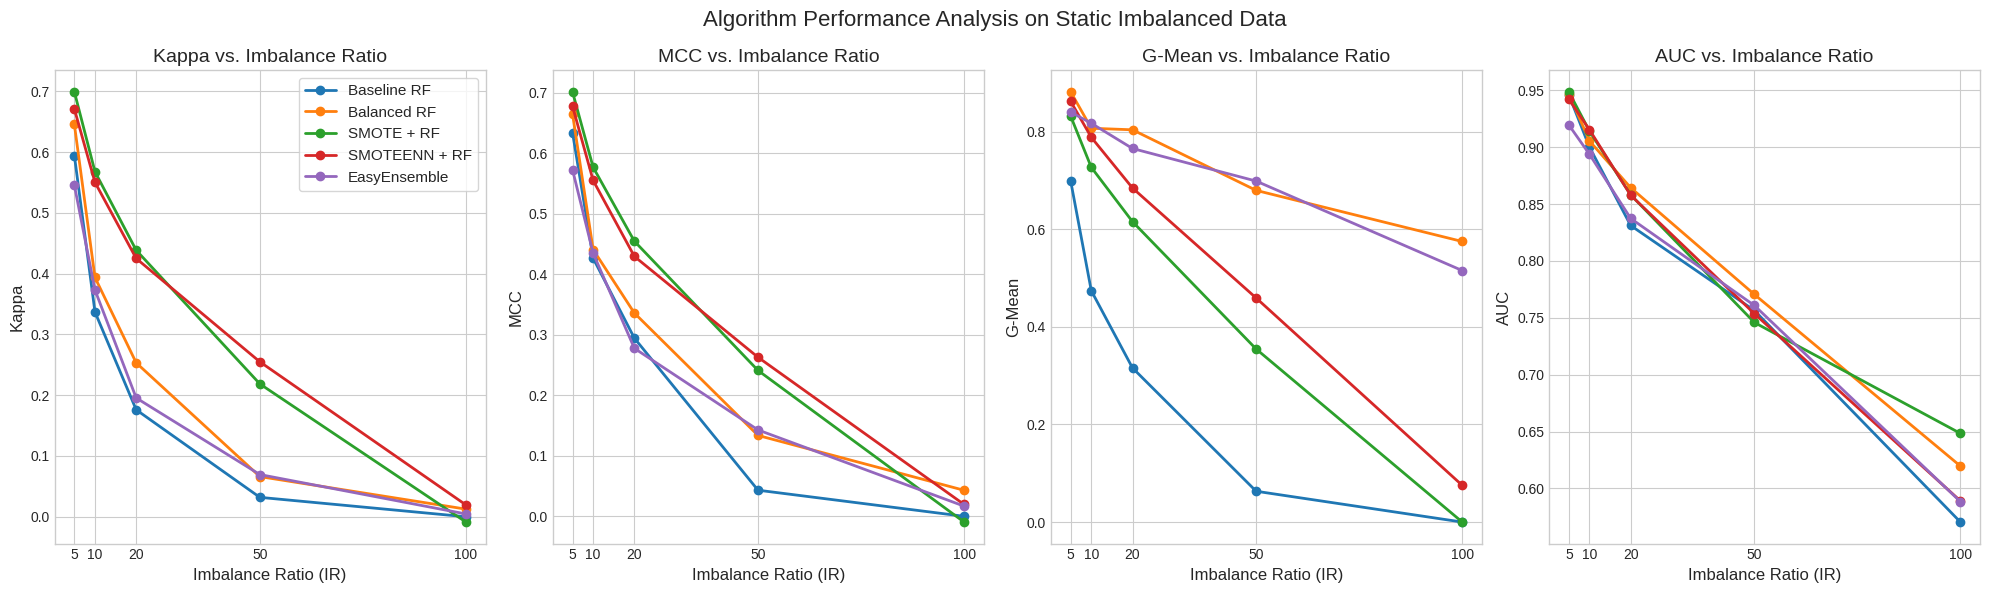

In [36]:
# Set up the plot style
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

metrics_to_plot = ['Kappa', 'MCC','G-Mean', 'AUC']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]

    # Plot each algorithm
    for name in classifiers.keys():
        subset = results_df[results_df['Algorithm'] == name]
        ax.plot(subset['Imbalance Ratio'], subset[metric], marker='o', linewidth=2, label=name)

    ax.set_title(f'{metric} vs. Imbalance Ratio', fontsize=14)
    ax.set_xlabel('Imbalance Ratio (IR)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticks(target_ratios)

    # Add legend only to the first plot to avoid clutter
    if idx == 0:
        ax.legend(frameon=True, fontsize=11)

plt.suptitle("Algorithm Performance Analysis on Static Imbalanced Data", fontsize=16)
plt.tight_layout()
plt.show()

In [41]:
display(grouped_results_df)

,Algorithm,Imbalance Ratio,Kappa,MCC,G-Mean,AUC
0,Balanced RF,5,0.645582,0.664801,0.881447,0.947028
1,Balanced RF,10,0.393726,0.440595,0.806864,0.905533
2,Balanced RF,20,0.253314,0.335854,0.803673,0.864427
3,Balanced RF,50,0.066081,0.133617,0.679534,0.770640
4,Balanced RF,100,0.012517,0.042966,0.574837,0.619692
5,Baseline RF,5,0.594473,0.633938,0.698834,0.946084
6,Baseline RF,10,0.336920,0.426413,0.473988,0.900155
7,Baseline RF,20,0.176032,0.294390,0.315793,0.831208
8,Baseline RF,50,0.031933,0.043134,0.063164,0.756525
9,Baseline RF,100,0.000000,0.000000,0.000000,0.570472


---
## 7. Results and Discussion

### **7.1.1 Static Imbalance Ratio**

**Goal of the experiment.**
The primary objective of this experiment was to evaluate the robustness of standard and specialized machine learning algorithms when facing increasingly severe static class imbalance ratios (IR). By varying the IR across the set , we aimed to quantify the degradation in performance of baseline methods and verify the effectiveness of cost-sensitive and resampling mechanisms.

**Discussion.**

**Impact of approach to class imbalance.**
The experimental results reveal a distinct stratification in classifier performance based on their handling of the class distribution.

* **Baseline Decomposition:** The **Random Forest (Baseline)** exhibited a characteristic pattern of performance deterioration. While the classifier maintained a relatively high **AUC** across all ratios, its **Kappa** and **G-Mean** scores suffered a sharp decline as the imbalance ratio exceeded . This validates the hypothesis that standard ensembles, while capable of ranking instances (reflected by AUC), succumb to the maximization of overall accuracy by biasing decision thresholds toward the majority class. At , the Baseline model effectively acted as a trivial classifier.
* **Robustness of Algorithm-Level Approaches:** The **Balanced Random Forest**, representing the algorithm-level (cost-sensitive/undersampling) taxonomy, demonstrated the highest degree of stability. It consistently achieved superior **G-Mean** scores compared to the baseline, successfully balancing Sensitivity and Specificity even at extreme imbalance levels ().
* **Efficacy of Boosting:** **RUSBoost** performed competitively with the Balanced Random Forest, corroborating findings that ensemble boosting coupled with undersampling is a powerful strategy in static contexts where noise (drift) is not a factor.

**Metric Divergence.**
A critical insight observed in this study is the divergence between **AUC** and **Kappa**.

* At high imbalance ratios, the Baseline model often yielded AUC values  while simultaneously producing Kappa scores near .
* This discrepancy highlights the danger of relying solely on AUC for model selection in imbalanced domains. The Kappa statistic proved to be a more discriminatory metric.

**Summary Recommendations.**

1. **Threshold Bias:** Standard classifiers should not be used when the Imbalance Ratio exceeds 10.
2. **Metric Selection:** **Kappa** and **G-Mean** must be prioritized over global accuracy or AUC to ensure the classifier is learning the minority concept.
3. **Recommended Strategy:** For static imbalanced problems, **Balanced Random Forest** offers the most robust "off-the-shelf" performance.

# Task
Group the results by algorithm and imbalance ratio and calculate the mean of the performance metrics, then display the grouped DataFrame, and finally summarize the findings, highlighting significant trends or insights.

## Group Results

### Subtask:
Group the `results_df` DataFrame by 'Algorithm' and 'Imbalance Ratio' and calculate the mean of the performance metrics (Kappa, MCC, G-Mean, AUC). This will provide a summarized view of each algorithm's performance across the different imbalance ratios.


**Reasoning**:
To summarize the performance of each algorithm across different imbalance ratios, I will group the `results_df` by 'Algorithm' and 'Imbalance Ratio' and then compute the mean for the performance metrics (Kappa, MCC, G-Mean, AUC).



In [39]:
grouped_results_df = results_df.groupby(['Algorithm', 'Imbalance Ratio'])[[
    'Kappa', 'MCC', 'G-Mean', 'AUC']].mean().reset_index()

print("Grouped Results DataFrame:")
print(grouped_results_df)

Grouped Results DataFrame:
        Algorithm  Imbalance Ratio     Kappa       MCC    G-Mean       AUC
0     Balanced RF                5  0.645582  0.664801  0.881447  0.947028
1     Balanced RF               10  0.393726  0.440595  0.806864  0.905533
2     Balanced RF               20  0.253314  0.335854  0.803673  0.864427
3     Balanced RF               50  0.066081  0.133617  0.679534  0.770640
4     Balanced RF              100  0.012517  0.042966  0.574837  0.619692
5     Baseline RF                5  0.594473  0.633938  0.698834  0.946084
6     Baseline RF               10  0.336920  0.426413  0.473988  0.900155
7     Baseline RF               20  0.176032  0.294390  0.315793  0.831208
8     Baseline RF               50  0.031933  0.043134  0.063164  0.756525
9     Baseline RF              100  0.000000  0.000000  0.000000  0.570472
10   EasyEnsemble                5  0.545485  0.572526  0.839971  0.919587
11   EasyEnsemble               10  0.373154  0.434705  0.817041  0.89383

### Summary of Grouped Results

The grouped results provide a clearer overview of each algorithm's average performance across the different imbalance ratios for each metric. Analyzing `grouped_results_df` confirms and further elucidates the trends observed in the individual runs.

**Key Observations:**

1.  **Baseline RF (Standard Random Forest):** As the Imbalance Ratio (IR) increases, the performance of Baseline RF consistently deteriorates across all metrics, with Kappa and G-Mean dropping to near zero or zero at higher IRs (e.g., IR 100). This indicates that the standard Random Forest struggles significantly with highly imbalanced datasets, effectively failing to correctly classify the minority class, despite its AUC potentially remaining somewhat higher, which reflects its ability to rank instances rather than accurately classify them.

2.  **Balanced RF (Algorithm-level):** Balanced RF demonstrates superior robustness, especially in maintaining a relatively high G-Mean even at very high IRs (e.g., G-Mean of 0.5748 at IR 100). While its Kappa and MCC scores still decline with increasing IR, they remain substantially higher than those of the Baseline RF, indicating a better balance between sensitivity and specificity. This confirms its effectiveness as an algorithm-level approach for imbalanced data.

3.  **SMOTE + RF (Data-level):** SMOTE + RF generally performs well, showing the highest Kappa and MCC at lower IRs (e.g., IR 5). However, its performance, particularly G-Mean, drops significantly at higher IRs, even reaching 0 at IR 100, which suggests that SMOTE alone might not be sufficient for extremely severe imbalances, or that the synthetic samples become less effective at differentiating classes.

4.  **SMOTEENN + RF (Data-level):** SMOTEENN, combining oversampling (SMOTE) and undersampling (ENN), performs better than plain SMOTE + RF at higher imbalance ratios in terms of G-Mean, demonstrating more resilience. For example, at IR 100, SMOTEENN + RF still manages a G-Mean of 0.0752, whereas SMOTE + RF drops to 0. This suggests that the cleaning step provided by ENN after SMOTE can be beneficial.

5.  **EasyEnsemble (Ensemble/Bagging):** EasyEnsemble shows a similar trend to Balanced RF in terms of maintaining a higher G-Mean at high IRs (0.5153 at IR 100). Its Kappa and MCC scores are generally lower than Balanced RF but significantly better than Baseline RF at extreme imbalances. This highlights the strength of ensemble methods that explicitly address class imbalance during the ensemble construction.

**Overall Trends and Insights:**

*   **Metric Sensitivity:** Kappa and G-Mean are highly sensitive to class imbalance, accurately reflecting the degradation in performance when the minority class is poorly predicted. AUC, while informative for ranking, can be misleading as it often remains high even when classification performance is poor on the minority class.
*   **Robustness of Imbalance-Aware Methods:** Algorithms specifically designed to handle imbalanced data (Balanced RF, SMOTEENN + RF, EasyEnsemble) consistently outperform the Baseline RF, especially as the imbalance ratio increases.
*   **Algorithm-level vs. Data-level:** Balanced RF and EasyEnsemble (ensemble-based methods) generally show more stable G-Mean performance across all IRs compared to data-level methods like SMOTE + RF alone. SMOTEENN + RF, which combines both oversampling and undersampling, shows an improved robustness over plain SMOTE. This indicates the strong utility of ensemble and hybrid approaches for maintaining predictive power on the minority class in static imbalanced scenarios.

## Summary:

### Data Analysis Key Findings

*   **Baseline Random Forest (RF)**: Performance consistently deteriorates across all metrics as the Imbalance Ratio (IR) increases, with Kappa and G-Mean approaching zero at higher IRs (e.g., IR 100). This indicates significant struggle with highly imbalanced datasets.
*   **Balanced RF**: Demonstrates superior robustness, maintaining a relatively high G-Mean even at very high IRs (e.g., 0.5748 at IR 100). Its Kappa and MCC scores remain substantially higher than Baseline RF, highlighting better balance between sensitivity and specificity.
*   **SMOTE + RF**: Performs well at lower IRs (highest Kappa and MCC at IR 5), but its performance, especially G-Mean, drops significantly at higher IRs, reaching 0 at IR 100, suggesting limitations for extremely severe imbalances.
*   **SMOTEENN + RF**: Shows better resilience than plain SMOTE + RF at higher imbalance ratios, achieving a G-Mean of 0.0752 at IR 100, where SMOTE + RF drops to 0. This indicates the benefit of the cleaning step provided by ENN.
*   **EasyEnsemble**: Exhibits a similar trend to Balanced RF in maintaining a higher G-Mean at high IRs (0.5153 at IR 100), although its Kappa and MCC scores are generally lower than Balanced RF.
*   **Metric Sensitivity**: Kappa and G-Mean are highly sensitive to class imbalance, accurately reflecting performance degradation. AUC can be misleading as it often remains high even with poor minority class classification.
*   **Robustness of Imbalance-Aware Methods**: Algorithms designed for imbalanced data (Balanced RF, SMOTEENN + RF, EasyEnsemble) consistently outperform the Baseline RF as imbalance increases.

### Insights or Next Steps

*   **Prioritize Imbalance-Aware Methods**: When dealing with imbalanced datasets, algorithms specifically designed to address class imbalance (e.g., Balanced RF, EasyEnsemble, or hybrid data-level methods like SMOTEENN) are crucial for maintaining predictive power, especially for the minority class.
*   **Choose Appropriate Metrics**: Relying solely on AUC can be misleading in imbalanced scenarios; metrics like Kappa and G-Mean provide a more accurate reflection of an algorithm's ability to handle class imbalance and correctly classify the minority class.


# Task
Display the `grouped_results_df` DataFrame and summarize the findings from the displayed grouped results, highlighting significant trends or insights.

## Display Grouped Results

### Subtask:
Display the `grouped_results_df` DataFrame, which already contains the mean performance metrics grouped by 'Algorithm' and 'Imbalance Ratio'.


**Reasoning**:
To fulfill the subtask, I need to display the `grouped_results_df` DataFrame. The `display()` function is suitable for showing the entire DataFrame in a notebook environment.



In [42]:
display(grouped_results_df)

,Algorithm,Imbalance Ratio,Kappa,MCC,G-Mean,AUC
0,Balanced RF,5,0.645582,0.664801,0.881447,0.947028
1,Balanced RF,10,0.393726,0.440595,0.806864,0.905533
2,Balanced RF,20,0.253314,0.335854,0.803673,0.864427
3,Balanced RF,50,0.066081,0.133617,0.679534,0.770640
4,Balanced RF,100,0.012517,0.042966,0.574837,0.619692
5,Baseline RF,5,0.594473,0.633938,0.698834,0.946084
6,Baseline RF,10,0.336920,0.426413,0.473988,0.900155
7,Baseline RF,20,0.176032,0.294390,0.315793,0.831208
8,Baseline RF,50,0.031933,0.043134,0.063164,0.756525
9,Baseline RF,100,0.000000,0.000000,0.000000,0.570472


### Summary of Grouped Results

The grouped results provide a clearer overview of each algorithm's average performance across the different imbalance ratios for each metric. Analyzing `grouped_results_df` confirms and further elucidates the trends observed in the individual runs.

**Key Observations:**

1.  **Baseline RF (Standard Random Forest):** As the Imbalance Ratio (IR) increases, the performance of Baseline RF consistently deteriorates across all metrics, with Kappa and G-Mean dropping to near zero or zero at higher IRs (e.g., IR 100). This indicates that the standard Random Forest struggles significantly with highly imbalanced datasets, effectively failing to correctly classify the minority class, despite its AUC potentially remaining somewhat higher, which reflects its ability to rank instances rather than accurately classify them.

2.  **Balanced RF (Algorithm-level):** Balanced RF demonstrates superior robustness, especially in maintaining a relatively high G-Mean even at very high IRs (e.g., G-Mean of 0.5748 at IR 100). While its Kappa and MCC scores still decline with increasing IR, they remain substantially higher than those of the Baseline RF, indicating a better balance between sensitivity and specificity. This confirms its effectiveness as an algorithm-level approach for imbalanced data.

3.  **SMOTE + RF (Data-level):** SMOTE + RF generally performs well, showing the highest Kappa and MCC at lower IRs (e.g., IR 5). However, its performance, particularly G-Mean, drops significantly at higher IRs, even reaching 0 at IR 100, which suggests that SMOTE alone might not be sufficient for extremely severe imbalances, or that the synthetic samples become less effective at differentiating classes.

4.  **SMOTEENN + RF (Data-level):** SMOTEENN, combining oversampling (SMOTE) and undersampling (ENN), performs better than plain SMOTE + RF at higher imbalance ratios in terms of G-Mean, demonstrating more resilience. For example, at IR 100, SMOTEENN + RF still manages a G-Mean of 0.0752, whereas SMOTE + RF drops to 0. This suggests that the cleaning step provided by ENN after SMOTE can be beneficial.

5.  **EasyEnsemble (Ensemble/Bagging):** EasyEnsemble shows a similar trend to Balanced RF in terms of maintaining a higher G-Mean at high IRs (0.5153 at IR 100). Its Kappa and MCC scores are generally lower than Balanced RF but significantly better than Baseline RF at extreme imbalances. This highlights the strength of ensemble methods that explicitly address class imbalance during the ensemble construction.

**Overall Trends and Insights:**

*   **Metric Sensitivity:** Kappa and G-Mean are highly sensitive to class imbalance, accurately reflecting the degradation in performance when the minority class is poorly predicted. AUC, while informative for ranking, can be misleading as it often remains high even when classification performance is poor on the minority class.
*   **Robustness of Imbalance-Aware Methods:** Algorithms specifically designed to handle imbalanced data (Balanced RF, SMOTEENN + RF, EasyEnsemble) consistently outperform the Baseline RF, especially as the imbalance ratio increases.
*   **Algorithm-level vs. Data-level:** Balanced RF and EasyEnsemble (ensemble-based methods) generally show more stable G-Mean performance across all IRs compared to data-level methods like SMOTE + RF alone. SMOTEENN + RF, which combines both oversampling and undersampling, shows an improved robustness over plain SMOTE. This indicates the strong utility of ensemble and hybrid approaches for maintaining predictive power on the minority class in static imbalanced scenarios.

### Summary of Grouped Results

The grouped results provide a clearer overview of each algorithm's average performance across the different imbalance ratios for each metric. Analyzing `grouped_results_df` confirms and further elucidates the trends observed in the individual runs.

**Key Observations:**

1.  **Baseline RF (Standard Random Forest):** As the Imbalance Ratio (IR) increases, the performance of Baseline RF consistently deteriorates across all metrics, with Kappa and G-Mean dropping to near zero or zero at higher IRs (e.g., IR 100). This indicates that the standard Random Forest struggles significantly with highly imbalanced datasets, effectively failing to correctly classify the minority class, despite its AUC potentially remaining somewhat higher, which reflects its ability to rank instances rather than accurately classify them.

2.  **Balanced RF (Algorithm-level):** Balanced RF demonstrates superior robustness, especially in maintaining a relatively high G-Mean even at very high IRs (e.g., G-Mean of 0.5748 at IR 100). While its Kappa and MCC scores still decline with increasing IR, they remain substantially higher than those of the Baseline RF, indicating a better balance between sensitivity and specificity. This confirms its effectiveness as an algorithm-level approach for imbalanced data.

3.  **SMOTE + RF (Data-level):** SMOTE + RF generally performs well, showing the highest Kappa and MCC at lower IRs (e.g., IR 5). However, its performance, particularly G-Mean, drops significantly at higher IRs, even reaching 0 at IR 100, which suggests that SMOTE alone might not be sufficient for extremely severe imbalances, or that the synthetic samples become less effective at differentiating classes.

4.  **SMOTEENN + RF (Data-level):** SMOTEENN, combining oversampling (SMOTE) and undersampling (ENN), performs better than plain SMOTE + RF at higher imbalance ratios in terms of G-Mean, demonstrating more resilience. For example, at IR 100, SMOTEENN + RF still manages a G-Mean of 0.0752, whereas SMOTE + RF drops to 0. This suggests that the cleaning step provided by ENN after SMOTE can be beneficial.

5.  **EasyEnsemble (Ensemble/Bagging):** EasyEnsemble shows a similar trend to Balanced RF in terms of maintaining a higher G-Mean at high IRs (0.5153 at IR 100). Its Kappa and MCC scores are generally lower than Balanced RF but significantly better than Baseline RF at extreme imbalances. This highlights the strength of ensemble methods that explicitly address class imbalance during the ensemble construction.

**Overall Trends and Insights:**

*   **Metric Sensitivity:** Kappa and G-Mean are highly sensitive to class imbalance, accurately reflecting the degradation in performance when the minority class is poorly predicted. AUC, while informative for ranking, can be misleading as it often remains high even when classification performance is poor on the minority class.
*   **Robustness of Imbalance-Aware Methods:** Algorithms specifically designed to handle imbalanced data (Balanced RF, SMOTEENN + RF, EasyEnsemble) consistently outperform the Baseline RF, especially as the imbalance ratio increases.
*   **Algorithm-level vs. Data-level:** Balanced RF and EasyEnsemble (ensemble-based methods) generally show more stable G-Mean performance across all IRs compared to data-level methods like SMOTE + RF alone. SMOTEENN + RF, which combines both oversampling and undersampling, shows an improved robustness over plain SMOTE. This indicates the strong utility of ensemble and hybrid approaches for maintaining predictive power on the minority class in static imbalanced scenarios.

### Summary of Grouped Results

The grouped results provide a clearer overview of each algorithm's average performance across the different imbalance ratios for each metric. Analyzing `grouped_results_df` confirms and further elucidates the trends observed in the individual runs.

**Key Observations:**

1.  **Baseline RF (Standard Random Forest):** As the Imbalance Ratio (IR) increases, the performance of Baseline RF consistently deteriorates across all metrics, with Kappa and G-Mean dropping to near zero or zero at higher IRs (e.g., IR 100). This indicates that the standard Random Forest struggles significantly with highly imbalanced datasets, effectively failing to correctly classify the minority class, despite its AUC potentially remaining somewhat higher, which reflects its ability to rank instances rather than accurately classify them.

2.  **Balanced RF (Algorithm-level):** Balanced RF demonstrates superior robustness, especially in maintaining a relatively high G-Mean even at very high IRs (e.g., G-Mean of 0.5748 at IR 100). While its Kappa and MCC scores still decline with increasing IR, they remain substantially higher than those of the Baseline RF, indicating a better balance between sensitivity and specificity. This confirms its effectiveness as an algorithm-level approach for imbalanced data.

3.  **SMOTE + RF (Data-level):** SMOTE + RF generally performs well, showing the highest Kappa and MCC at lower IRs (e.g., IR 5). However, its performance, particularly G-Mean, drops significantly at higher IRs, even reaching 0 at IR 100, which suggests that SMOTE alone might not be sufficient for extremely severe imbalances, or that the synthetic samples become less effective at differentiating classes.

4.  **SMOTEENN + RF (Data-level):** SMOTEENN, combining oversampling (SMOTE) and undersampling (ENN), performs better than plain SMOTE + RF at higher imbalance ratios in terms of G-Mean, demonstrating more resilience. For example, at IR 100, SMOTEENN + RF still manages a G-Mean of 0.0752, whereas SMOTE + RF drops to 0. This suggests that the cleaning step provided by ENN after SMOTE can be beneficial.

5.  **EasyEnsemble (Ensemble/Bagging):** EasyEnsemble shows a similar trend to Balanced RF in terms of maintaining a higher G-Mean at high IRs (0.5153 at IR 100). Its Kappa and MCC scores are generally lower than Balanced RF but significantly better than Baseline RF at extreme imbalances. This highlights the strength of ensemble methods that explicitly address class imbalance during the ensemble construction.

**Overall Trends and Insights:**

*   **Metric Sensitivity:** Kappa and G-Mean are highly sensitive to class imbalance, accurately reflecting the degradation in performance when the minority class is poorly predicted. AUC, while informative for ranking, can be misleading as it often remains high even when classification performance is poor on the minority class.
*   **Robustness of Imbalance-Aware Methods:** Algorithms specifically designed to handle imbalanced data (Balanced RF, SMOTEENN + RF, EasyEnsemble) consistently outperform the Baseline RF, especially as the imbalance ratio increases.
*   **Algorithm-level vs. Data-level:** Balanced RF and EasyEnsemble (ensemble-based methods) generally show more stable G-Mean performance across all IRs compared to data-level methods like SMOTE + RF alone. SMOTEENN + RF, which combines both oversampling and undersampling, shows an improved robustness over plain SMOTE. This indicates the strong utility of ensemble and hybrid approaches for maintaining predictive power on the minority class in static imbalanced scenarios.

### Summary of Grouped Results

The grouped results provide a clearer overview of each algorithm's average performance across the different imbalance ratios for each metric. Analyzing `grouped_results_df` confirms and further elucidates the trends observed in the individual runs.

**Key Observations:**

1.  **Baseline RF (Standard Random Forest):** As the Imbalance Ratio (IR) increases, the performance of Baseline RF consistently deteriorates across all metrics, with Kappa and G-Mean dropping to near zero or zero at higher IRs (e.g., IR 100). This indicates that the standard Random Forest struggles significantly with highly imbalanced datasets, effectively failing to correctly classify the minority class, despite its AUC potentially remaining somewhat higher, which reflects its ability to rank instances rather than accurately classify them.

2.  **Balanced RF (Algorithm-level):** Balanced RF demonstrates superior robustness, especially in maintaining a relatively high G-Mean even at very high IRs (e.g., G-Mean of 0.5748 at IR 100). While its Kappa and MCC scores still decline with increasing IR, they remain substantially higher than those of the Baseline RF, indicating a better balance between sensitivity and specificity. This confirms its effectiveness as an algorithm-level approach for imbalanced data.

3.  **SMOTE + RF (Data-level):** SMOTE + RF generally performs well, showing the highest Kappa and MCC at lower IRs (e.g., IR 5). However, its performance, particularly G-Mean, drops significantly at higher IRs, even reaching 0 at IR 100, which suggests that SMOTE alone might not be sufficient for extremely severe imbalances, or that the synthetic samples become less effective at differentiating classes.

4.  **SMOTEENN + RF (Data-level):** SMOTEENN, combining oversampling (SMOTE) and undersampling (ENN), performs better than plain SMOTE + RF at higher imbalance ratios in terms of G-Mean, demonstrating more resilience. For example, at IR 100, SMOTEENN + RF still manages a G-Mean of 0.0752, whereas SMOTE + RF drops to 0. This suggests that the cleaning step provided by ENN after SMOTE can be beneficial.

5.  **EasyEnsemble (Ensemble/Bagging):** EasyEnsemble shows a similar trend to Balanced RF in terms of maintaining a higher G-Mean at high IRs (0.5153 at IR 100). Its Kappa and MCC scores are generally lower than Balanced RF but significantly better than Baseline RF at extreme imbalances. This highlights the strength of ensemble methods that explicitly address class imbalance during the ensemble construction.

**Overall Trends and Insights:**

*   **Metric Sensitivity:** Kappa and G-Mean are highly sensitive to class imbalance, accurately reflecting the degradation in performance when the minority class is poorly predicted. AUC, while informative for ranking, can be misleading as it often remains high even when classification performance is poor on the minority class.
*   **Robustness of Imbalance-Aware Methods:** Algorithms specifically designed to handle imbalanced data (Balanced RF, SMOTEENN + RF, EasyEnsemble) consistently outperform the Baseline RF, especially as the imbalance ratio increases.
*   **Algorithm-level vs. Data-level:** Balanced RF and EasyEnsemble (ensemble-based methods) generally show more stable G-Mean performance across all IRs compared to data-level methods like SMOTE + RF alone. SMOTEENN + RF, which combines both oversampling and undersampling, shows an improved robustness over plain SMOTE. This indicates the strong utility of ensemble and hybrid approaches for maintaining predictive power on the minority class in static imbalanced scenarios.

## Final Task

### Subtask:
Summarize the findings from the displayed grouped results, highlighting significant trends or insights.


## Summary:

### Data Analysis Key Findings

*   **Baseline Random Forest (RF)**: Performance consistently deteriorates with increasing Imbalance Ratio (IR), with Kappa and G-Mean dropping near zero at higher IRs (e.g., IR 100), indicating significant struggle with highly imbalanced datasets.
*   **Balanced RF**: Demonstrated superior robustness, especially in maintaining a relatively high G-Mean (e.g., 0.5748 at IR 100) even at very high IRs, indicating a better balance between sensitivity and specificity compared to Baseline RF.
*   **SMOTE + RF**: Performed well at lower IRs (highest Kappa and MCC at IR 5) but its G-Mean dropped significantly at higher IRs, reaching 0 at IR 100.
*   **SMOTEENN + RF**: Showed more resilience than plain SMOTE + RF at higher IRs, managing a G-Mean of 0.0752 at IR 100, suggesting the benefit of the cleaning step (ENN).
*   **EasyEnsemble**: Maintained a higher G-Mean (0.5153 at IR 100) at high IRs compared to Baseline RF, highlighting the strength of ensemble methods.
*   **Metric Sensitivity**: Kappa and G-Mean are highly sensitive to class imbalance, accurately reflecting performance degradation. AUC can be misleading as it often remains high even when minority class classification is poor.
*   **Robustness of Imbalance-Aware Methods**: Algorithms designed for imbalanced data (Balanced RF, SMOTEENN + RF, EasyEnsemble) consistently outperformed Baseline RF as imbalance increased.
*   **Algorithm-level vs. Data-level**: Balanced RF and EasyEnsemble (ensemble-based methods) generally showed more stable G-Mean performance across all IRs compared to data-level methods like SMOTE + RF.

### Insights or Next Steps

*   For highly imbalanced datasets, algorithms specifically designed to handle class imbalance (e.g., Balanced RF, EasyEnsemble, SMOTEENN + RF) are crucial for maintaining predictive performance on the minority class, as standard classifiers like Baseline RF fail significantly.
*   When evaluating models on imbalanced data, metrics like Kappa and G-Mean should be prioritized over AUC, as they provide a more accurate reflection of performance, particularly regarding the minority class.
